In [1]:
import spacy
from spacytextblob.spacytextblob import SpacyTextBlob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import chain

In [2]:
nlp = spacy.load("en_core_web_lg")
nlp.add_pipe("spacytextblob")

In [3]:
def get_paragraphs_from_file(path: str):
    with open(path, encoding="utf-8") as file:
        contents = file.read()
    
    lines = contents.splitlines()
    return [line for line in lines if line] # Filter out empty string lines

In [4]:
CORPUS_PATH = Path("corpus")

In [5]:
def get_paragraphs_df_from_corpus(gender: str):
    gender_path = CORPUS_PATH / gender

    files = [file for file in gender_path.iterdir() if file.is_file()]
    paragraphs_per_file = [get_paragraphs_from_file(file) for file in files]
    paragraphs = list(chain.from_iterable(paragraphs_per_file))

    paragraphs_df = pd.DataFrame({"paragraph": paragraphs})
    paragraphs_df["gender"] = gender

    return paragraphs_df

In [12]:
genders = ["man", "woman", "equal", "genderless"]

In [ ]:
df = pd.concat([
    get_paragraphs_df_from_corpus(gender)
    for gender in genders
])
df.head()

,paragraph,gender
0,Steve Garcia and David Onama clash in a battle...,man
1,After starting his career with a 1-2 mark in t...,man
2,Onama suffered the first loss of his career in...,man
3,A week before the welterweight title goes on t...,man
4,The 28-year-old Bonfim has been on an upward t...,man


In [7]:
# This cell might take a while, have patience
df["doc"] = list(nlp.pipe(df["paragraph"]))
df.head()

,paragraph,gender,doc
0,Steve Garcia and David Onama clash in a battle...,man,"(Steve, Garcia, and, David, Onama, clash, in, ..."
1,After starting his career with a 1-2 mark in t...,man,"(After, starting, his, career, with, a, 1, -, ..."
2,Onama suffered the first loss of his career in...,man,"(Onama, suffered, the, first, loss, of, his, c..."
3,A week before the welterweight title goes on t...,man,"(A, week, before, the, welterweight, title, go..."
4,The 28-year-old Bonfim has been on an upward t...,man,"(The, 28, -, year, -, old, Bonfim, has, been, ..."


In [8]:
df["polarity"] = df["doc"].apply(lambda doc: doc._.blob.polarity)
df["subjectivity"] = df["doc"].apply(lambda doc: doc._.blob.subjectivity)
df.head()

,paragraph,gender,doc,polarity,subjectivity
0,Steve Garcia and David Onama clash in a battle...,man,"(Steve, Garcia, and, David, Onama, clash, in, ...",0.208333,0.333333
1,After starting his career with a 1-2 mark in t...,man,"(After, starting, his, career, with, a, 1, -, ...",0.003241,0.394444
2,Onama suffered the first loss of his career in...,man,"(Onama, suffered, the, first, loss, of, his, c...",0.128571,0.433333
3,A week before the welterweight title goes on t...,man,"(A, week, before, the, welterweight, title, go...",0.300000,0.600000
4,The 28-year-old Bonfim has been on an upward t...,man,"(The, 28, -, year, -, old, Bonfim, has, been, ...",0.261111,0.280556


In [9]:
sns.set_theme()

<Axes: xlabel='polarity', ylabel='gender'>

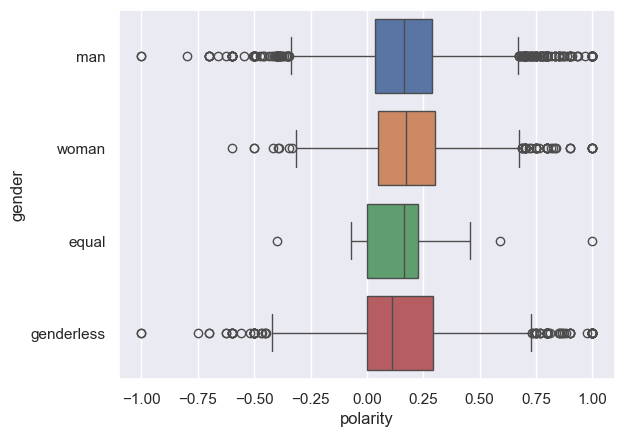

In [10]:
sns.boxplot(data=df, x="polarity", y="gender", hue="gender", legend=False)

<Axes: xlabel='subjectivity', ylabel='gender'>

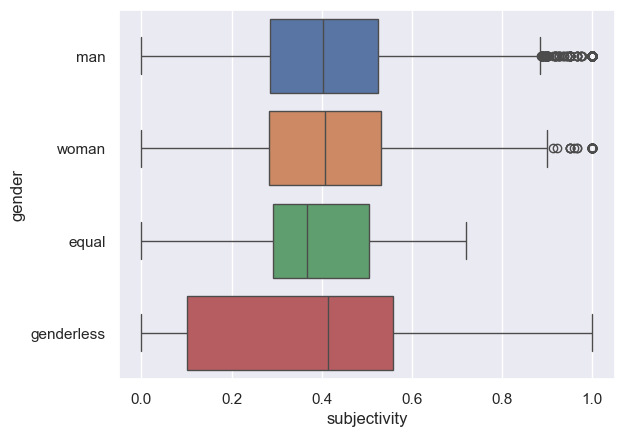

In [11]:
sns.boxplot(data=df, x="subjectivity", y="gender", hue="gender", legend=False)

In [ ]:
summary_df = pd.DataFrame(
    data={
        "mean polarity": df.groupby("gender")["polarity"].mean(),
        "median polarity": df.groupby("gender")["polarity"].median(),
        "mean subjectivity": df.groupby("gender")["subjectivity"].mean(),
        "median subjectivity": df.groupby("gender")["subjectivity"].median(),
    }
)
summary_df

,mean polarity,median polarity,mean subjectivity,median subjectivity
gender,,,,
equal,0.157275,0.165476,0.355074,0.367500
genderless,0.161480,0.113492,0.376609,0.413333
man,0.178884,0.166241,0.403899,0.403175
woman,0.190839,0.172822,0.410084,0.406580
